In [6]:
import numpy as np
import pandas as pd

In [14]:
from Data.data_cleaning import Datacleaner

cleaner = Datacleaner("./Data/Datasets/ligue1_2010_2025.csv")

cleaner = (cleaner.drop_useless_columns()
           .drop_rows(row_idxs=[1520,2281])
           .fillNA(column='Div',value='F1')
           .fillNA(column='Time', value='00:00')
           .add_season())

cleaner.save_data("Data/Datasets/Match_dataset_clean.csv")

c:\Leo_Perso\ENSAE\3A\Advanced ML\Projet ML\Learning-Latent-Football-Team-Strengths\Data\data_cleaning.py:26: DtypeWarning: Columns (139) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(filepath)


In [1]:
from Data.data_preparing import DataPreparer

preparer = DataPreparer(match_data_filepath="Data/Datasets/Match_dataset_clean.csv",
                        market_value_filepath="Data/Datasets/ligue1_market_values_2010_2025.csv")

# Save Features DataFrame
preparer.feature_engineering(save=True, display=False)

df = preparer.merge_df(save=True)

Processing complete. Saving merged dataframe to 'Complete_df.csv'.


In [2]:
from Data.data_processing import DataProcesser

processer = DataProcesser("Data/Datasets/Complete_df.csv")

processer.remove_year("25-26")

train_df, test_df = processer.split_train_test(test_size=306)

train_data, test_data = processer.get_train_test_data()

In [ ]:
from BradleyTerry_classical.functions import BT_calibrate

# Calibrate Hyperparameter Lambda

Lambda_Chooser = BT_calibrate(train_data=train_data)

lambda_grid = np.linspace(-3,2,30)

Lambda_Chooser.calibrate_lambda(lambda_grid=lambda_grid)

In [3]:
from BradleyTerry_classical.BT_classical import BradleyTerry

# Train the model
bt_model = BradleyTerry(lambda_draw=-0.24, learning_rate=0.01, n_iterations=1000)
bt_model.fit(train_data=train_data)

strength = bt_model.predict_strength()

Tolerance threshold attained after 333 iterations
Model fitted successfully !


In [4]:
from Neural_Bradley_Terry.NeuralBT import NeuralBradleyTerry, get_start_year


Number of matches (Before 24-25) : 5145
Used seasons : ['10-11' '11-12' '12-13' '13-14' '14-15' '15-16' '16-17' '17-18' '18-19'
 '19-20' '20-21' '21-22' '22-23' '23-24']
Training with time-decayed weights


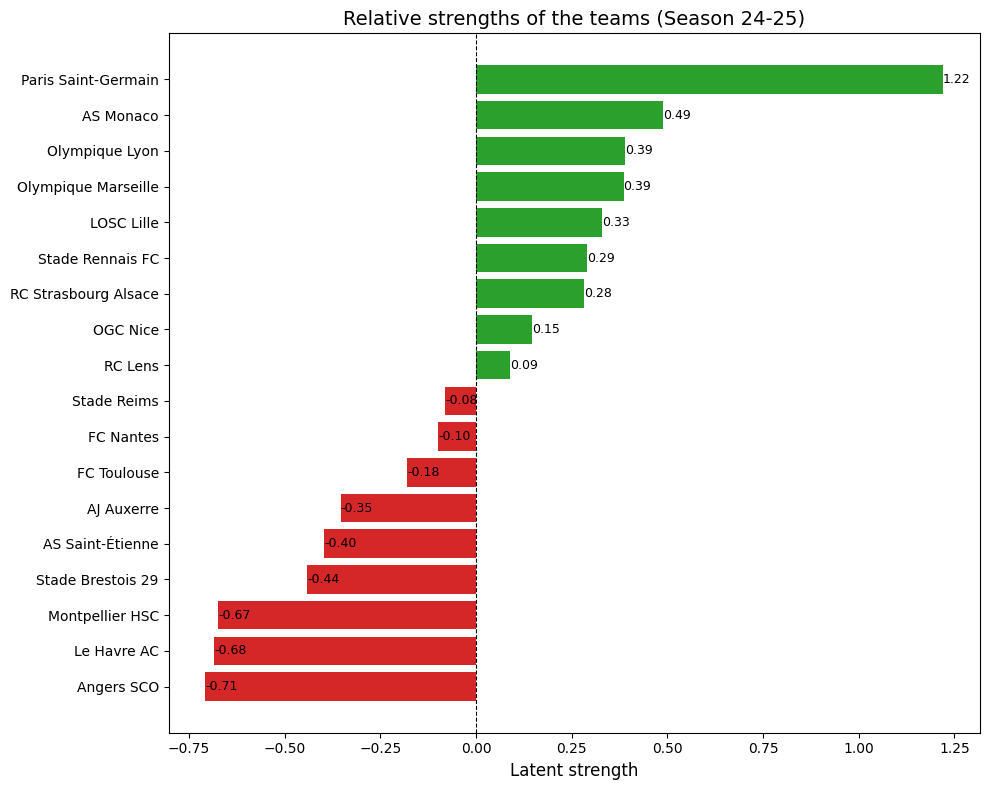

In [7]:
import matplotlib.pyplot as plt

# Used features (every variable is explicitly named in the dataset)
feature_names = [
    'Log_Market_Value',     
    'Strength_Rank_Based',   
    'Pythagorean_Exp',       
    'Avg_Goals_Scored',      
    'Home_Dependency',
    'Avg_Shots_Target',  
    'Avg_Corners',       
    'Avg_Cards'        
    ]

target_season = '24-25' 

model = NeuralBradleyTerry(input_dim=len(feature_names))

# Training data (all seasons before the target season)
df_train = df[df['Season'] != target_season].copy()
target_year =get_start_year(target_season)
df_train = df[df['Season'].apply(get_start_year) < target_year].copy()

# Info to be sure of the data used

print(f"Number of matches (Before {target_season}) : {len(df_train)}")
print(f"Used seasons : {df_train['Season'].unique()}")
seasons = df_train['Season'].values

X_home = df_train[[f"{col}_Home" for col in feature_names]].values.astype(np.float32)
X_away = df_train[[f"{col}_Away" for col in feature_names]].values.astype(np.float32)
y = df_train['Target'].values.astype(np.float32)

# Training loop and print results


model.fit(X_home, X_away, y, seasons, epochs=500)

ranking = model.get_season_ranking(df, target_season, feature_names)

if ranking is not None:
    mean_strength = ranking['Neural_Strength'].mean()
    ranking['Centered_Strength'] = ranking['Neural_Strength'] - mean_strength # Centering around the mean
    plt.figure(figsize=(10, 8))
    df_plot = ranking.head(18).copy() #18 teams in the french league
    colors = ['#2ca02c' if x > 0 else '#d62728' for x in df_plot['Centered_Strength']]
    plt.barh(df_plot['Team'], df_plot['Centered_Strength'], color=colors)
    plt.axvline(0, color='black', linewidth=0.8, linestyle='--') 
    plt.gca().invert_yaxis() 
    plt.title(f"Relative strengths of the teams (Season {target_season})", fontsize=14)
    plt.xlabel("Latent strength", fontsize=12)
    for index, value in enumerate(df_plot['Centered_Strength']):
        plt.text(value, index, f"{value:.2f}", va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

# Simulation part 

# Thresholds can be adjusted to simulate more or less draws
df_probas = model.predict_season_probas(df, target_season, feature_names, draw_threshold=0.5, home_advantage=0.3)

if df_probas is not None:
    df_probas.to_csv(f"Predictions_{target_season}.csv", index=False)